# I2SB sampling from a trained run

Loads a trained I2SB run **entirely from its saved `config.json`** (model, bridge schedule, and
the data block -- including your `image_key`, so it matches whatever normalization you trained on),
applies the **EMA** weights, and runs the reverse bridge `x1 (T1) -> x0 (T1CE)`.

Point `CONFIG_PATH` at your run's `config.json`; everything else is read from it. Run on the HPC
node where the data + checkpoints live.

In [1]:
import os, sys, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# ---- point this at your trained run ----
CONFIG_PATH = "trained_nets/brats/I2SB_paper_baseline_T1ce_from_ALL/config.json"

# ---- sampling knobs ----
SPLIT     = "val"      # which data split to sample from
USE_EMA   = True       # sample with EMA weights (recommended)
NFE       = 100        # number of denoising steps (higher = better/slower; < n_points)
OT_ODE    = None       # None = use config's ot_ode; True = deterministic; False = stochastic
LOG_COUNT = 6          # trajectory frames to keep

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
npy = lambda t: t.detach().cpu().numpy()
print("repo:", REPO_ROOT, "| device:", device)

repo: /scratch/ee2178/ImMAP | device: cuda


## 1. Load config, build model, apply EMA

In [2]:
from models import build_model

with open(CONFIG_PATH) as f:
    cfg = json.load(f)
ic = cfg["i2sb"]

save_dir  = os.path.dirname(CONFIG_PATH)
ckpt_path = os.path.join(save_dir, "net.ckpt")     # derive from the config dir (robust)
ema_path  = os.path.join(save_dir, "ema.pt")

net = build_model(cfg).to(device)                  # saved config has init disabled
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
net.load_state_dict(ckpt["model_state_dict"])
net.eval()
print(f"loaded net weights from {ckpt_path} (step {ckpt.get('step')})")

def apply_ema_(net, ema_path, device):
    """Copy the saved EMA shadow into the model params (same order the EMA class used)."""
    sd = torch.load(ema_path, map_location=device, weights_only=False)
    params = [p for p in net.parameters() if p.requires_grad]
    shadow = sd["shadow"]
    assert len(params) == len(shadow), f"EMA/param mismatch: {len(shadow)} vs {len(params)}"
    for p, s in zip(params, shadow):
        p.data.copy_(s.to(p.device))

if USE_EMA and os.path.exists(ema_path):
    apply_ema_(net, ema_path, device); print(f"applied EMA weights from {ema_path}")
elif USE_EMA:
    print(f"[warn] {ema_path} not found -> sampling with raw weights")

print("model :", cfg["model"]["type"], cfg["model"]["params"])
print("i2sb  :", ic)
print("data  : image_key =", cfg["data"][SPLIT].get("image_key", "img"),
      "| scales =", cfg["data"][SPLIT].get("scales"))

loaded net weights from trained_nets/brats/I2SB_paper_baseline_T1ce_from_ALL/net.ckpt (step 275900)
applied EMA weights from trained_nets/brats/I2SB_paper_baseline_T1ce_from_ALL/ema.pt
model : CDLNet {'K': 30, 'M': 169, 'P': 7, 's': 2, 'C': 4, 't0': 0.0, 'adaptive': True, 'init': False, 'complex': False}
i2sb  : {'bridge_type': 'i2sb', 'tau': 1.0, 'n_points': 1000, 'bridge_shape': 'constant', 'beta_max': 0.3, 'ot_ode': False, 'parameterization': 'x0', 'clip_denoise': False, 'ema_decay': 0.99, 'val_mode': 'single_pass', 'val_nfe': 20, 'target_channels': 1}
data  : image_key = img | scales = [1, 1, 1, 1]


## 2. Rebuild the bridge schedule from the config

In [3]:
from sb.base import build_schedule, n_steps, bridge_coeffs

bridge = build_schedule(
    kind=ic.get("kind", "brownian"),
    n_points=ic.get("n_points", 1000),
    device=device,
    tau=ic.get("tau", 0.19),
    beta_max=ic.get("beta_max", 0.3),
)
N = n_steps(bridge)
print(f"bridge_type = {ic.get('kind')}   n_points = {N}")
print(f"max std_fwd (sigma ceiling) = {float(bridge.std_fwd.max()):.4f}")
print(f"max std_sb  (peak noise)    = {float(bridge_coeffs(bridge)[2].max()):.4f}")
assert 0 < NFE < N, f"NFE must be in (0, {N})" 

bridge_type = i2sb   n_points = 1000
max std_fwd (sigma ceiling) = 0.3755
max std_sb  (peak noise)    = 0.1879


## 3. Load data exactly as trained

In [4]:
import datasets                          # registers the loaders
from datasets.registry import build_loader

data_cfg = dict(cfg["data"][SPLIT])
data_cfg["num_workers"] = 0
loader = build_loader(data_cfg, shuffle=True, drop_last=False)

x0, x1, cond, mask = next(iter(loader))    # x0 = T1CE (GT), x1 = T1 (prior)
x0, x1, mask = x0.to(device), x1.to(device), mask.to(device)
cond = cond.to(device); cond = cond if cond.shape[1] > 0 else None
print("x0 (T1CE GT) :", tuple(x0.shape))
print("x1 (T1 prior):", tuple(x1.shape))
print("cond         :", None if cond is None else tuple(cond.shape))

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


x0 (T1CE GT) : (8, 1, 240, 240)
x1 (T1 prior): (8, 1, 240, 240)
cond         : (8, 3, 240, 240)


## 4. Run I2SB sampling  (`x1 -> x0`)

In [5]:
from sb.i2sb import i2sb_sample

deterministic = ic.get("deterministic", False) if OT_ODE is None else OT_ODE
t0 = time.time()
recon, xs, pred_x0s = i2sb_sample(
    net, x1, bridge, cond=cond, nfe=NFE, deterministic=deterministic,
    clip_denoise=ic.get("clip_denoise", False),
    target_channels=ic.get("target_channels", 1),
    log_count=LOG_COUNT, verbose=True,
)
print()
print(f"sampled {recon.shape[0]} images in {time.time()-t0:.1f}s "
      f"(nfe={NFE}, deterministic={deterministic})")
print("recon:", tuple(recon.shape), " | trajectory xs:", tuple(xs.shape))

I2SB sampling: 100%|██████████| 100/100 [00:13<00:00,  7.17it/s]


sampled 8 images in 14.0s (nfe=100, ot_ode=False, param=x0)
recon: (8, 1, 240, 240)  | trajectory xs: (8, 6, 1, 240, 240)


## 5. Results:  `T1 prior | sampled T1CE | GT T1CE | residual`

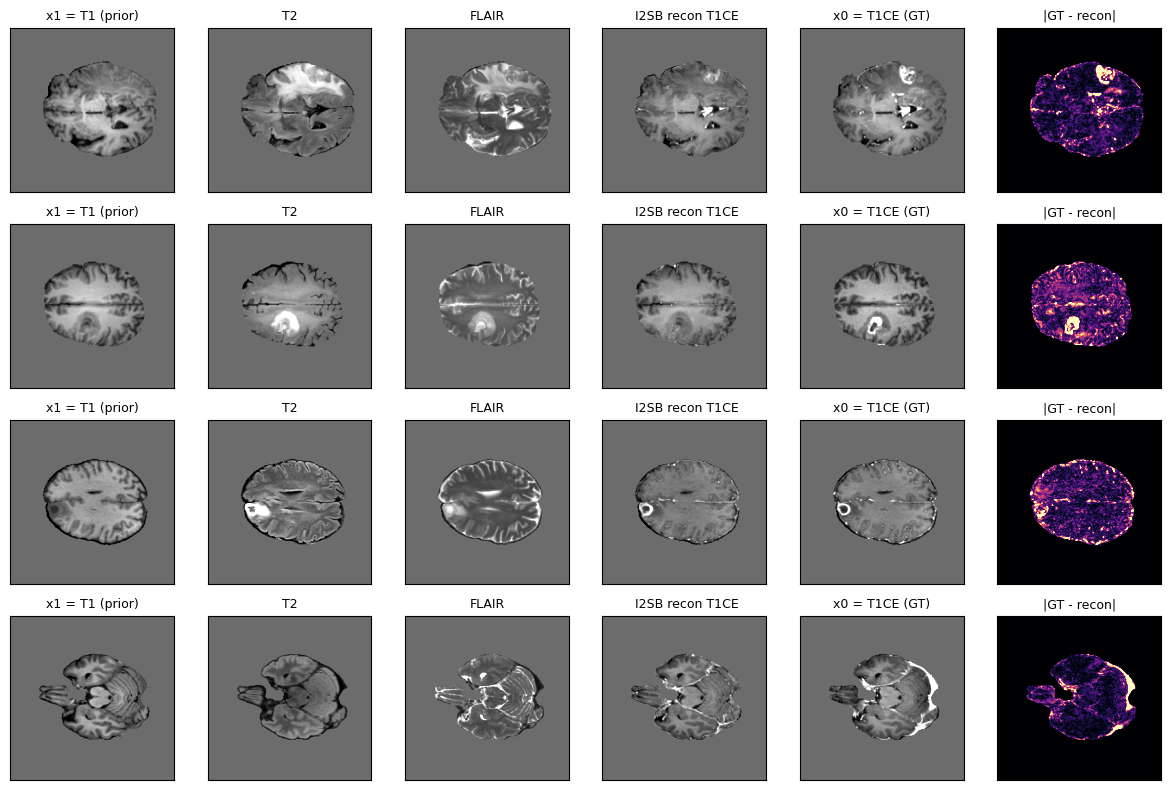

In [14]:
from training.metrics import compute_metrics
from training.common import apply_loss_mask

def disp_window(*imgs, m=None, lo=1, hi=99):
    vals = [(im[m.bool().expand_as(im)] if m is not None else im).flatten() for im in imgs]
    v = torch.cat(vals).float().cpu()
    if v.numel() > 1_000_000:
        v = v[torch.randint(0, v.numel(), (1_000_000,))]
    return float(torch.quantile(v, lo / 100)), float(torch.quantile(v, hi / 100))

x0m, reconm = apply_loss_mask(x0, recon, mask, use_mask=True)
nshow = min(4, x0.shape[0])
vmin, vmax = disp_window(x1[:nshow], x0[:nshow], m=mask[:nshow])

fig, ax = plt.subplots(nshow, 6, figsize=(12, 2 * nshow))
ax = np.atleast_2d(ax)
for i in range(nshow):
    g, r = x0m[i:i+1], reconm[i:i+1]
    mets = compute_metrics(g, r, psnr_only=False)
    res  = (g - r).abs()
    panels = [(x1[i, 0], "x1 = T1 (prior)"),
              (cond[i, 0], "T2"),
              (cond[i, 2], "FLAIR"),
              (reconm[i, 0], f" I2SB recon T1CE"),
              (x0m[i, 0], "x0 = T1CE (GT)")]
    for a, (im, ttl) in zip(ax[i, :5], panels):
        a.imshow(npy(im), cmap="gray", vmin=vmin, vmax=vmax); a.set_title(ttl, fontsize=9)
    rr = npy(res[0, 0])
    ax[i, 5].imshow(rr, cmap="magma", vmin=0, vmax=np.percentile(rr, 99))
    ax[i, 5].set_title("|GT - recon|", fontsize=9)
    for a in ax[i]: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Reverse-sampling trajectory (one example)

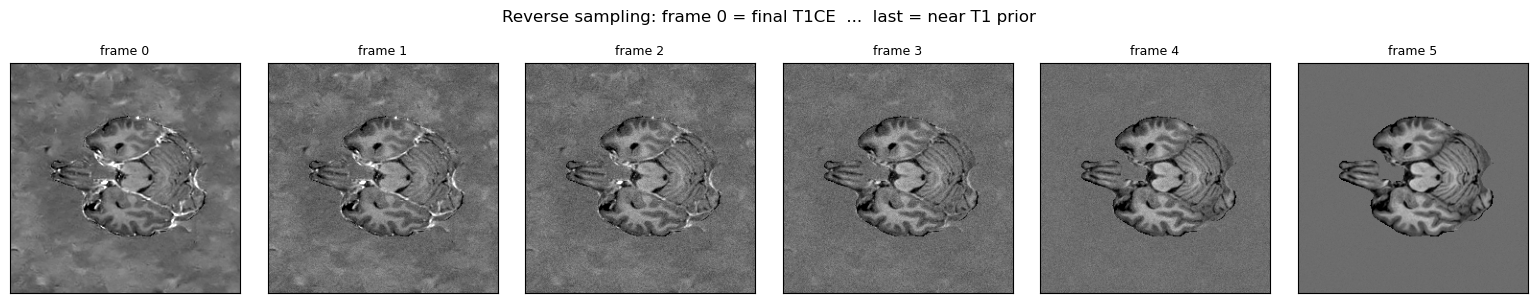

In [8]:
b = 3
traj = xs[b]                      # (LOG_COUNT, 1, H, W); frame 0 = final T1CE, last = near T1
L = traj.shape[0]
fig, ax = plt.subplots(1, L, figsize=(2.6 * L, 2.9))
for j in range(L):
    ax[j].imshow(npy(traj[j, 0]), cmap="gray", vmin=vmin, vmax=vmax)
    ax[j].set_xticks([]); ax[j].set_yticks([]); ax[j].set_title(f"frame {j}", fontsize=9)
fig.suptitle("Reverse sampling: frame 0 = final T1CE  ...  last = near T1 prior", y=1.03)
plt.tight_layout(); plt.show()

## 7. Aggregate metrics over a few val batches (optional)

Full sampling per batch, so keep `N_BATCHES` small unless you want to wait.

In [15]:
N_BATCHES = 4
agg = {"psnr": 0.0, "ssim": 0.0, "nrmse": 0.0}
n = 0
it = iter(loader)
for bi in range(N_BATCHES):
    try:
        a0, a1, ac, am = next(it)
    except StopIteration:
        break
    a0, a1, am = a0.to(device), a1.to(device), am.to(device)
    ac = ac.to(device); ac = ac if ac.shape[1] > 0 else None
    rc, _, _ = i2sb_sample(net, a1, bridge, cond=ac, nfe=NFE, deterministic=deterministic,
                           clip_denoise=ic.get("clip_denoise", False),
                           target_channels=ic.get("target_channels", 1),
                           log_count=1, verbose=False)
    g, r = apply_loss_mask(a0, rc, am, use_mask=True)
    m = compute_metrics(g, r, psnr_only=False)
    bs = a0.shape[0]
    for k in agg: agg[k] += float(m[k]) * bs
    n += bs
    print(f"batch {bi+1}/{N_BATCHES}: PSNR={float(m['psnr']):.2f} "
          f"SSIM={float(m['ssim']):.3f} NRMSE={float(m['nrmse']):.4f}  (n={n})")
print()
print(f"MEAN over {n} images:", {k: round(v / max(n, 1), 4) for k, v in agg.items()})

batch 1/4: PSNR=8.32 SSIM=0.811 NRMSE=0.0298  (n=8)
batch 2/4: PSNR=7.97 SSIM=0.810 NRMSE=0.0319  (n=16)
batch 3/4: PSNR=9.10 SSIM=0.801 NRMSE=0.0268  (n=24)
batch 4/4: PSNR=9.39 SSIM=0.824 NRMSE=0.0249  (n=32)

MEAN over 32 images: {'psnr': 8.6958, 'ssim': 0.8116, 'nrmse': 0.0283}


ImMAP-SB: 100%|██████████| 100/100 [00:12<00:00,  8.04it/s, t=0.9000]


ImMAP-SB: 100 iterations, final t = 0.9000


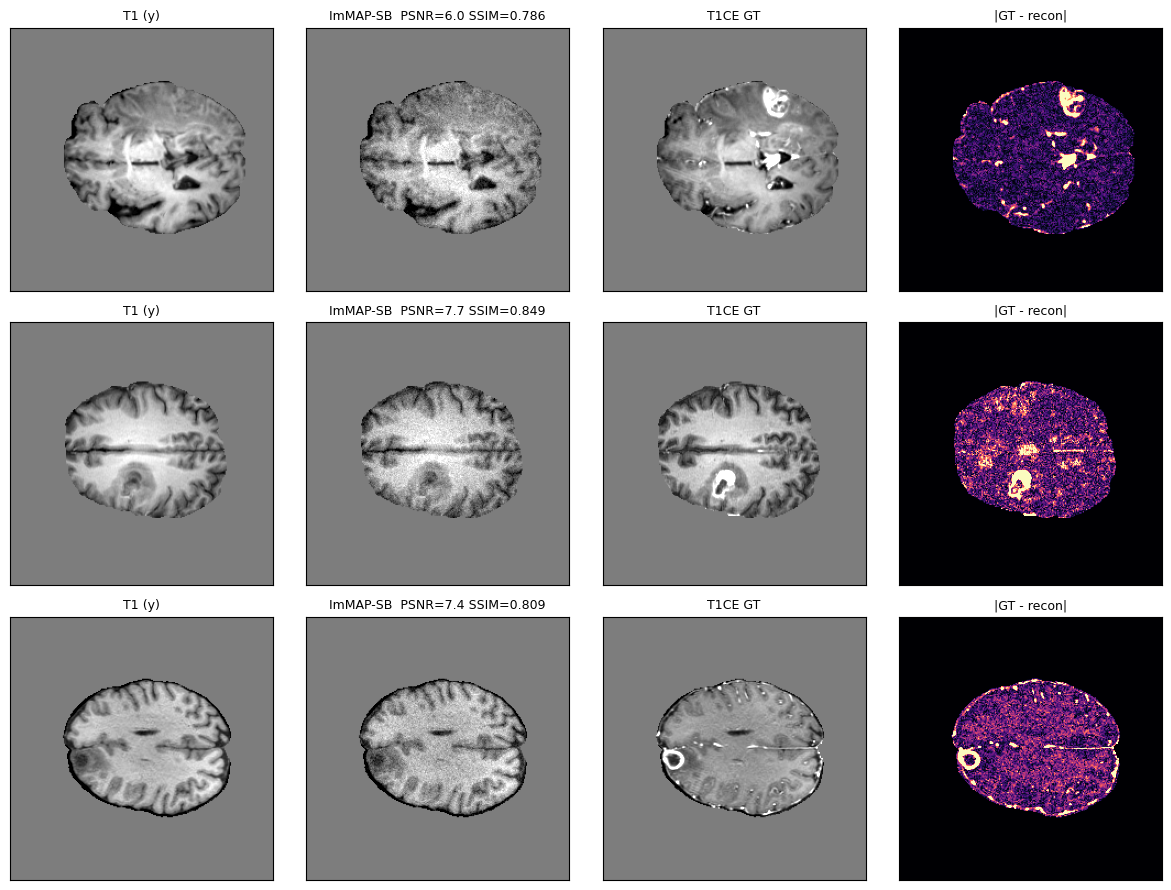

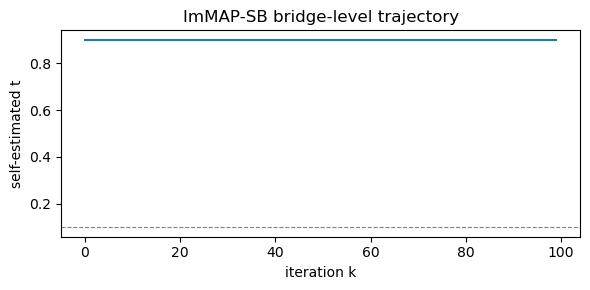

In [16]:
from sb.immap_sb import immap_sb

# --- ImMAP-SB knobs ---
TAU_SB, BETA_SB = 1.0, 0.1   # bridge noise scale, injection ratio in [0,1]
T_L, H0         = 0.1, 1.0                   # stopping level, initial step size
INIT_T          = 0.9                        # first-step seed (<1); 1.0 -> literal (stuck)
MONOTONE        = False                        # True -> force t non-increasing (stabilizer)
MAX_ITER        = 100

x_sb, ts, _ = immap_sb(
    net, x1, bridge, cond=cond,
    tau=ic.get("tau", 0.19), beta=BETA_SB, t_L=T_L, h_0=H0,
    init_t=INIT_T, warm_start=True, warm_start_noise=True, monotone=True,
    target_channels=ic.get("target_channels", 1), max_iter=MAX_ITER, verbose=True,
)
print(f"ImMAP-SB: {len(ts)} iterations, final t = {ts[-1]:.4f}")

# results panel + t-trajectory
x0m, x_sbm = apply_loss_mask(x0, x_sb, mask, use_mask=True)
nshow = min(3, x0.shape[0])
vmin, vmax = disp_window(x1[:nshow], x0[:nshow], m=mask[:nshow])
fig, ax = plt.subplots(nshow, 4, figsize=(12, 3 * nshow)); ax = np.atleast_2d(ax)
for i in range(nshow):
    g, r = x0m[i:i+1], x_sbm[i:i+1]
    mets = compute_metrics(g, r, psnr_only=False)
    rr = npy((g - r).abs()[0, 0])
    panels = [(x1[i, 0], "T1 (y)"),
              (x_sbm[i, 0], f"ImMAP-SB  PSNR={float(mets['psnr']):.1f} SSIM={float(mets['ssim']):.3f}"),
              (x0m[i, 0], "T1CE GT")]
    for a, (im, ttl) in zip(ax[i, :3], panels):
        a.imshow(npy(im), cmap="gray", vmin=vmin, vmax=vmax); a.set_title(ttl, fontsize=9)
    ax[i, 3].imshow(rr, cmap="magma", vmin=0, vmax=np.percentile(rr, 99)); ax[i, 3].set_title("|GT - recon|", fontsize=9)
    for a in ax[i]: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 3)); plt.plot(ts); plt.axhline(T_L, ls="--", c="gray", lw=0.8)
plt.xlabel("iteration k"); plt.ylabel("self-estimated t"); plt.title("ImMAP-SB bridge-level trajectory")
plt.tight_layout(); plt.show()

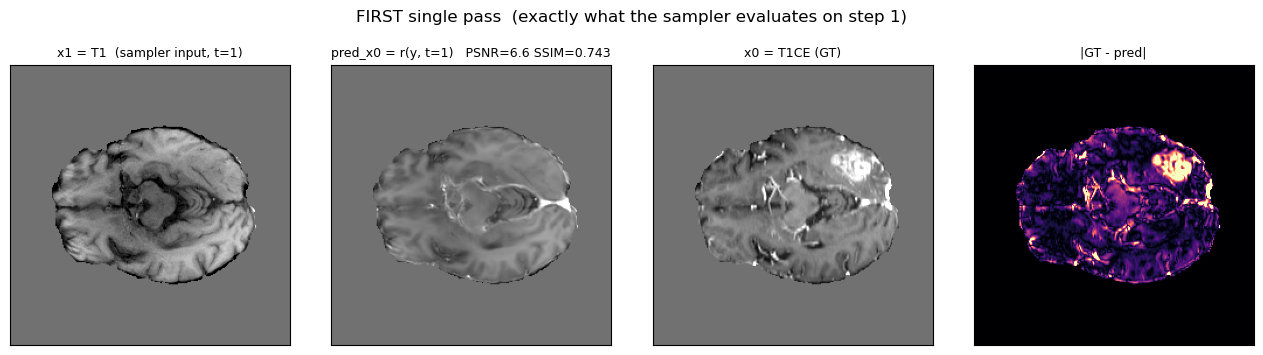

In [10]:
from sb.base import forward_sample, forward_std, predict_x0

EX    = 3                                     # which slice in the batch
N     = n_steps(bridge)
xb0, xb1, mb = x0[EX:EX+1], x1[EX:EX+1], mask[EX:EX+1]   # x0=T1CE GT, x1=T1 prior (=y)
cb    = None if cond is None else cond[EX:EX+1]
param = ic.get("parameterization", "x0")
tc    = ic.get("target_channels", 1)

def single_pass(x_t, step_idx):
    """One network eval -> predicted x0 (handles x0/eps parameterization)."""
    step  = torch.full((x_t.shape[0],), int(step_idx), device=device, dtype=torch.long)
    sigma = forward_std(bridge, step, xdim=x_t.shape[1:])
    out   = predict_x0(net, x_t, sigma, cond=cb, target_channels=tc)
    return out

vmin, vmax = disp_window(xb1, xb0, m=mb)

# ---- 1) the EXACT first sampling step:  pred_x0 = r(x_t = x1 = y,  t = 1) ----
pred0 = single_pass(xb1, N - 1)
g, r  = apply_loss_mask(xb0, pred0, mb, use_mask=True)
mets  = compute_metrics(g, r, psnr_only=False)
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
for a, (im, ttl) in zip(ax[:3],
        [(xb1[0,0], "x1 = T1  (sampler input, t=1)"),
         (r[0,0], f"pred_x0 = r(y, t=1)   PSNR={float(mets['psnr']):.1f} SSIM={float(mets['ssim']):.3f}"),
         (g[0,0], "x0 = T1CE (GT)")]):
    a.imshow(npy(im), cmap="gray", vmin=vmin, vmax=vmax); a.set_title(ttl, fontsize=9)
rr = npy((g - r).abs()[0, 0]); ax[3].imshow(rr, cmap="magma", vmin=0, vmax=np.percentile(rr, 99))
ax[3].set_title("|GT - pred|", fontsize=9)
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.suptitle("FIRST single pass  (exactly what the sampler evaluates on step 1)", y=1.03)
plt.tight_layout(); plt.show()

# # ---- 2) single-pass denoise across bridge levels t  (input x_t  vs  network pred_x0) ----
# T_FRACS = [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
# torch.manual_seed(0)
# fig, ax = plt.subplots(2, len(T_FRACS), figsize=(2.5 * len(T_FRACS), 5.3))
# for j, tf in enumerate(T_FRACS):
#     k    = int(round(tf * (N - 1)))
#     step = torch.full((1,), k, device=device, dtype=torch.long)
#     x_t  = forward_sample(bridge, step, xb0, xb1, deterministic=False)      # true bridge input (as in training)
#     gk, rk = apply_loss_mask(xb0, single_pass(x_t, k), mb, use_mask=True)
#     ps = float(compute_metrics(gk, rk, psnr_only=True)['psnr'])
#     ax[0, j].imshow(npy(x_t[0, 0]), cmap="gray", vmin=vmin, vmax=vmax); ax[0, j].set_title(f"x_t  t={tf:.2f}", fontsize=9)
#     ax[1, j].imshow(npy(rk[0, 0]), cmap="gray", vmin=vmin, vmax=vmax); ax[1, j].set_title(f"pred_x0  PSNR={ps:.1f}", fontsize=9)
#     for a in (ax[0, j], ax[1, j]): a.set_xticks([]); a.set_yticks([])
# ax[0, 0].set_ylabel("input  x_t", fontsize=11); ax[1, 0].set_ylabel("network pred_x0", fontsize=11)
# fig.suptitle("Single-pass denoise vs bridge level  (top: input,  bottom: predicted T1CE)", y=1.0)
# plt.tight_layout(); plt.show()

# # ---- 3) single-pass PSNR as a function of t  (where does the denoiser break?) ----
# ts_grid = np.linspace(0.02, 0.99, 20); torch.manual_seed(0); psnrs = []
# for tf in ts_grid:
#     k    = int(round(tf * (N - 1)))
#     step = torch.full((1,), k, device=device, dtype=torch.long)
#     x_t  = forward_sample(bridge, step, xb0, xb1, deterministic=False)
#     gk, rk = apply_loss_mask(xb0, single_pass(x_t, k), mb, use_mask=True)
#     psnrs.append(float(compute_metrics(gk, rk, psnr_only=True)['psnr']))
# plt.figure(figsize=(6.5, 3.6)); plt.plot(ts_grid, psnrs, marker='o')
# plt.xlabel("bridge level t   (0 = near T1CE,  1 = near T1 prior)")
# plt.ylabel("single-pass pred_x0 PSNR (dB)")
# plt.title("Denoiser quality vs bridge level"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [62]:
from sb.base import forward_std, predict_x0
from utils.tensor import unsqueeze_xdim

# --- match the ImMAP-SB run you're debugging ---
TAU_SB, BETA_SB = ic.get("tau", 0.19), 1.0
H0, INIT_T, MONOTONE = 0.5, 0.75, False
N_PASSES = 5
EX = 3
param, tc = ic.get("parameterization", "x0"), ic.get("target_channels", 1)

y  = x1[EX:EX+1].to(device)                      # x1 = T1 prior = y
cb = None if cond is None else cond[EX:EX+1]
N  = n_steps(bridge)

@torch.no_grad()
def regress(x_t, t_val):
    """One network eval at continuous bridge level t_val -> predicted x0."""
    k   = torch.full((x_t.shape[0],), int(round(float(t_val) * (N - 1))), device=device, dtype=torch.long)
    sig = forward_std(bridge, k, xdim=x_t.shape[1:])
    out = predict_x0(net, x_t, sig, cond=cb, target_channels=tc)
    return out

def masked_norm2(img, mask):
    """
    Compute the masked ℓ2 norm of an image.

    Args:
        img: Tensor of any shape.
        mask: Boolean or {0,1} tensor broadcastable to img.

    Returns:
        Scalar tensor containing the masked ℓ2 norm.
    """
    mask = mask.to(dtype=img.dtype)
    return torch.sqrt(torch.sum(mask * img.abs().square()))

gen = torch.Generator(device=device).manual_seed(0)
x, xd = y.clone(), y.clone()          # x = full (with noise);  xd = deterministic-only copy
t, td = float(INIT_T), float(INIT_T)

# y = t*y+(1-t)*xb0
print(f"{'pass':>4} | {'gamma':>8} {'||det||':>9} {'||noise||':>9} {'noise/det':>10} | "
      f"{'t_est FULL':>11} {'t_est NO-NOISE':>14}")
for k in range(1, N_PASSES + 1):
    # ---- full track (noise on) ----
    x0h  = regress(x, t)
    # Force a warm start at t = 0.75
    x = x0h*(1-t)+t*(y) + t*(1-t)*TAU_SB*torch.randn_like(x)
    num  = float(masked_norm2(x0h - x, mb))
    den = float(masked_norm2(x0h-y, mb))
    ratio = num / den
    if k > 1: t = min(ratio, 1.0) if not MONOTONE else min(min(ratio, 1.0), t)
    # h_k = H0 * k / (1 + H0 * (k - 1))
    h_k = H0
    inj = (1 - BETA_SB * h_k) ** 2 - (1 - h_k) ** 2
    # gamma = (t * (1 - t) * TAU_SB * max(inj, 0.0)) ** 0.5
    gamma = (t * (1 - t) * TAU_SB)
    # print("num = " +str(num))
    # print("den = " +str(den))
    # print("h_k = " +str(h_k))
    # print("gamma = " +str(gamma))
    print("ratio = " +str(ratio))
    print("t = " +str(t) + ", gamma = " +str(gamma))
    # print("t = " +str(t))
    u = (1 - t) * x0h + t*y
    det   = h_k * (u - x)
    noise = gamma * torch.randn(x.shape, generator=gen, device=device)

    # # ---- deterministic-only track (same everything, noise off) ----
    # x0hd  = regress(xd, td)
    # numd  = float((x0hd - xd).flatten(1).norm()); dend = max(float((x0hd - y).flatten(1).norm()), 1e-8)
    # ratiod = numd / dend
    # if k > 1: td = min(ratiod, 1.0) if not MONOTONE else min(min(ratiod, 1.0), td)
    # detd  = h_k * ((1 - td) * x0hd + td * y - xd)

    # dn, nn_ = float(det.flatten().norm()), float(noise.flatten().norm())
    # # print(f"{k:>4} | {gamma:8.4f} {dn:9.4f} {nn_:9.4f} {nn_/max(dn,1e-9):10.1f} | {ratio:11.4f} {ratiod:14.4f}")

    x  = x + det + noise
    # xd = xd + detd

pass |    gamma   ||det|| ||noise||  noise/det |  t_est FULL t_est NO-NOISE
ratio = 0.8211726818217088
t = 0.75, gamma = 0.1875
ratio = 0.7929031939824155
t = 0.7929031939824155, gamma = 0.1642077189548995
ratio = 0.8127633625118185
t = 0.8127633625118185, gamma = 0.15217907907030082
ratio = 0.8294248495918485
t = 0.8294248495918485, gamma = 0.141479268471388
ratio = 0.8435404709853969
t = 0.8435404709853969, gamma = 0.1319799447951317


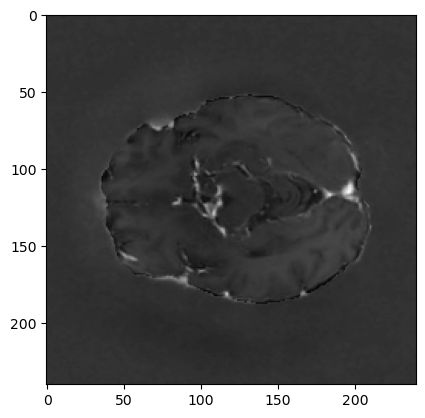

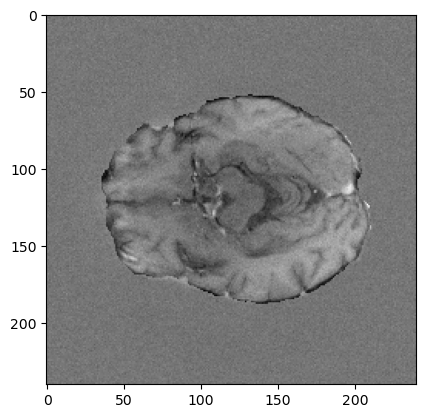

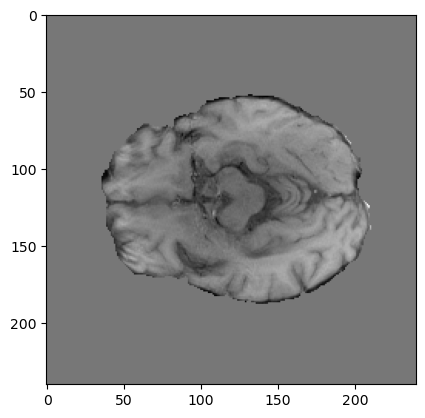

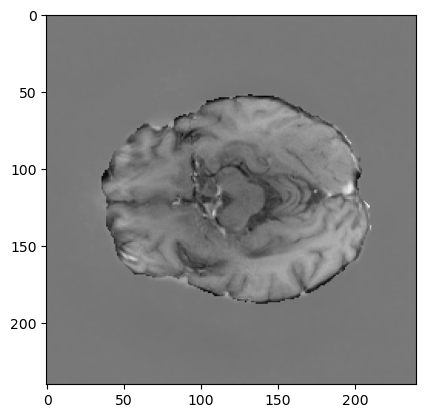

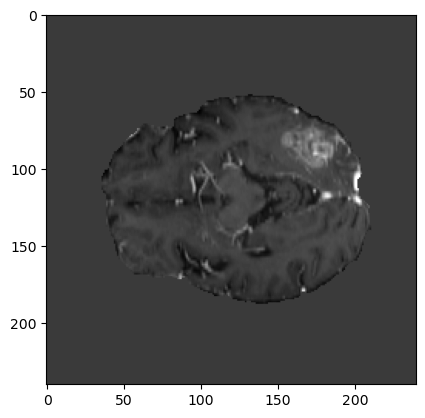

In [60]:
plt.imshow((x0h).detach().cpu().squeeze(), cmap = 'gray')
plt.show()
plt.imshow(x.detach().cpu().squeeze(), cmap = 'gray')
plt.show()
plt.imshow(y.detach().cpu().squeeze(), cmap = 'gray')
plt.show()
plt.imshow(u.detach().cpu().squeeze(), cmap = 'gray')
plt.show()
plt.imshow(x0m[EX].detach().cpu().squeeze(), cmap = 'gray')
plt.show()
# plt.imshow(mb.detach().cpu().squeeze())
# plt.show()

In [13]:
def hist(img, bins=256, title="Image Histogram", density=False):
    """
    Plot the histogram of a PyTorch image.

    Args:
        img: Tensor of shape (..., H, W) or any shape.
        bins: Number of histogram bins.
        title: Plot title.
        density: If True, normalize the histogram.
    """
    if isinstance(img, torch.Tensor):
        data = img.detach().cpu().float().flatten().numpy()
    else:
        data = img.flatten()

    plt.figure(figsize=(5, 3))
    plt.hist(data, bins=bins, density=density)
    plt.xlabel("Pixel value")
    plt.ylabel("Density" if density else "Count")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

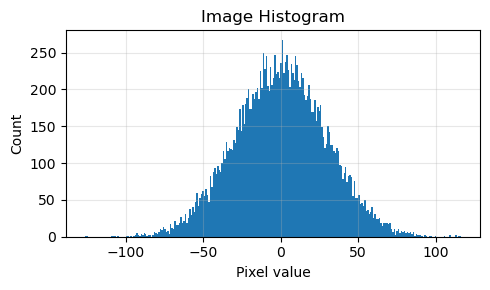

In [14]:
hist(x[mb.bool()])

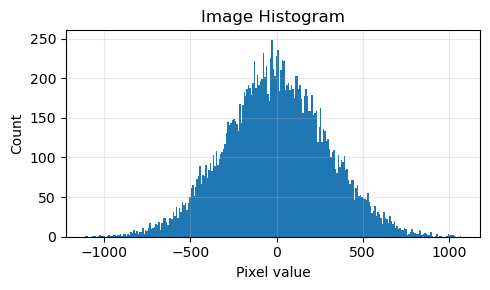

In [15]:
hist((x-x0h)[mb.bool()])

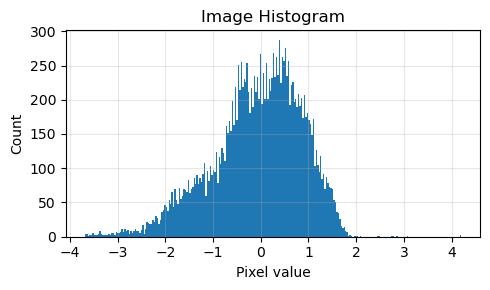

In [16]:
hist(y[mb.bool()])